# RVQ Exploration with Encodec  

Code from the post: https://mikexcohen.substack.com/p/exploring-a-residual-vector-quantization

Some key references here:
* The paper of Encodec: https://arxiv.org/pdf/2210.13438
* The model on huggingFace https://huggingface.co/facebook/encodec_24khz

<i>Using the code without reading the post may lead to confusion or errors.</i>

**Why any of this matters:** a single 10-second clip of stereo audio at CD-quality (44.1 kHz) is already 882,000 numbers. Video, music streaming, voice calls — none of it would be practical to send around the internet raw. Residual vector quantization is one of the cleverer answers to *'how do we shrink this without it sounding terrible?'* — and by the end of this notebook you'll have compressed a real speech clip to well under 1% of its original size and still understood every word.

In [ ]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from IPython.display import Audio as ipAudio # different name b/c of datasets:Audio

from datasets import load_dataset, Audio
from transformers import EncodecModel, AutoProcessor

In [ ]:
### matplotlib adjustments (for dark mode)

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'figure.facecolor': '#191919',#'#282a2c',
    'figure.edgecolor': '#191919',
    'axes.facecolor':   '#191919',
    'axes.edgecolor':   '#DDE2F4',
    'axes.labelcolor':  '#DDE2F4',
    'xtick.color':      '#DDE2F4',
    'ytick.color':      '#DDE2F4',
    'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300
})

# **Demo of simple quantization**

In [ ]:
y = np.cumsum(np.random.randn(100))

qy = np.digitize(y,np.linspace(y.min(),y.max(),4))

fig,ax = plt.subplots(1,figsize=(8,3))
ax.plot(y,'w')

ax2 = ax.twinx()
ax2.plot(qy,'s',color=[.9,.3,.3])
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color([.9,.3,.3])

ax.set(xlabel='Time (a.u.)',ylabel='Waveform amplitude')
ax2.set(yticks=range(1,5),ylabel='Quantized bin')
plt.show()

This toy example is quantization at its crudest: chop a continuous signal into a handful of amplitude bins and call it a day. It's a fair mental starting point, but it's also a bit of a dead end — you've thrown away detail *without* actually shrinking the number of time points. Real audio codecs need something smarter, which is exactly where the model below comes in.

# Import model and process data

Here's the idea that makes vector quantization actually useful, instead of the crude bin-chopping above: instead of labeling *individual amplitudes*, label *chunks of pattern*. 

Think of a song's verse-chorus structure — once you've heard the chorus once, you don't need it spelled out again; you can just say 'chorus' and everyone knows what comes next. A vector quantizer's *codewords* work the same way: each one is a short, learned spectral-temporal pattern (tens of milliseconds of sound), and the *codebook* is the model's whole vocabulary of these patterns. Compressing the signal then just means writing down which pattern played, and when — a sequence of integers, exactly like token IDs in a language model (in fact, if you've played with LLMs, a codebook here is basically a token-embedding table). 

You can also think of each codeword as a k-means centroid: every little chunk of (heavily transformed) signal gets snapped to whichever learned pattern it most resembles.

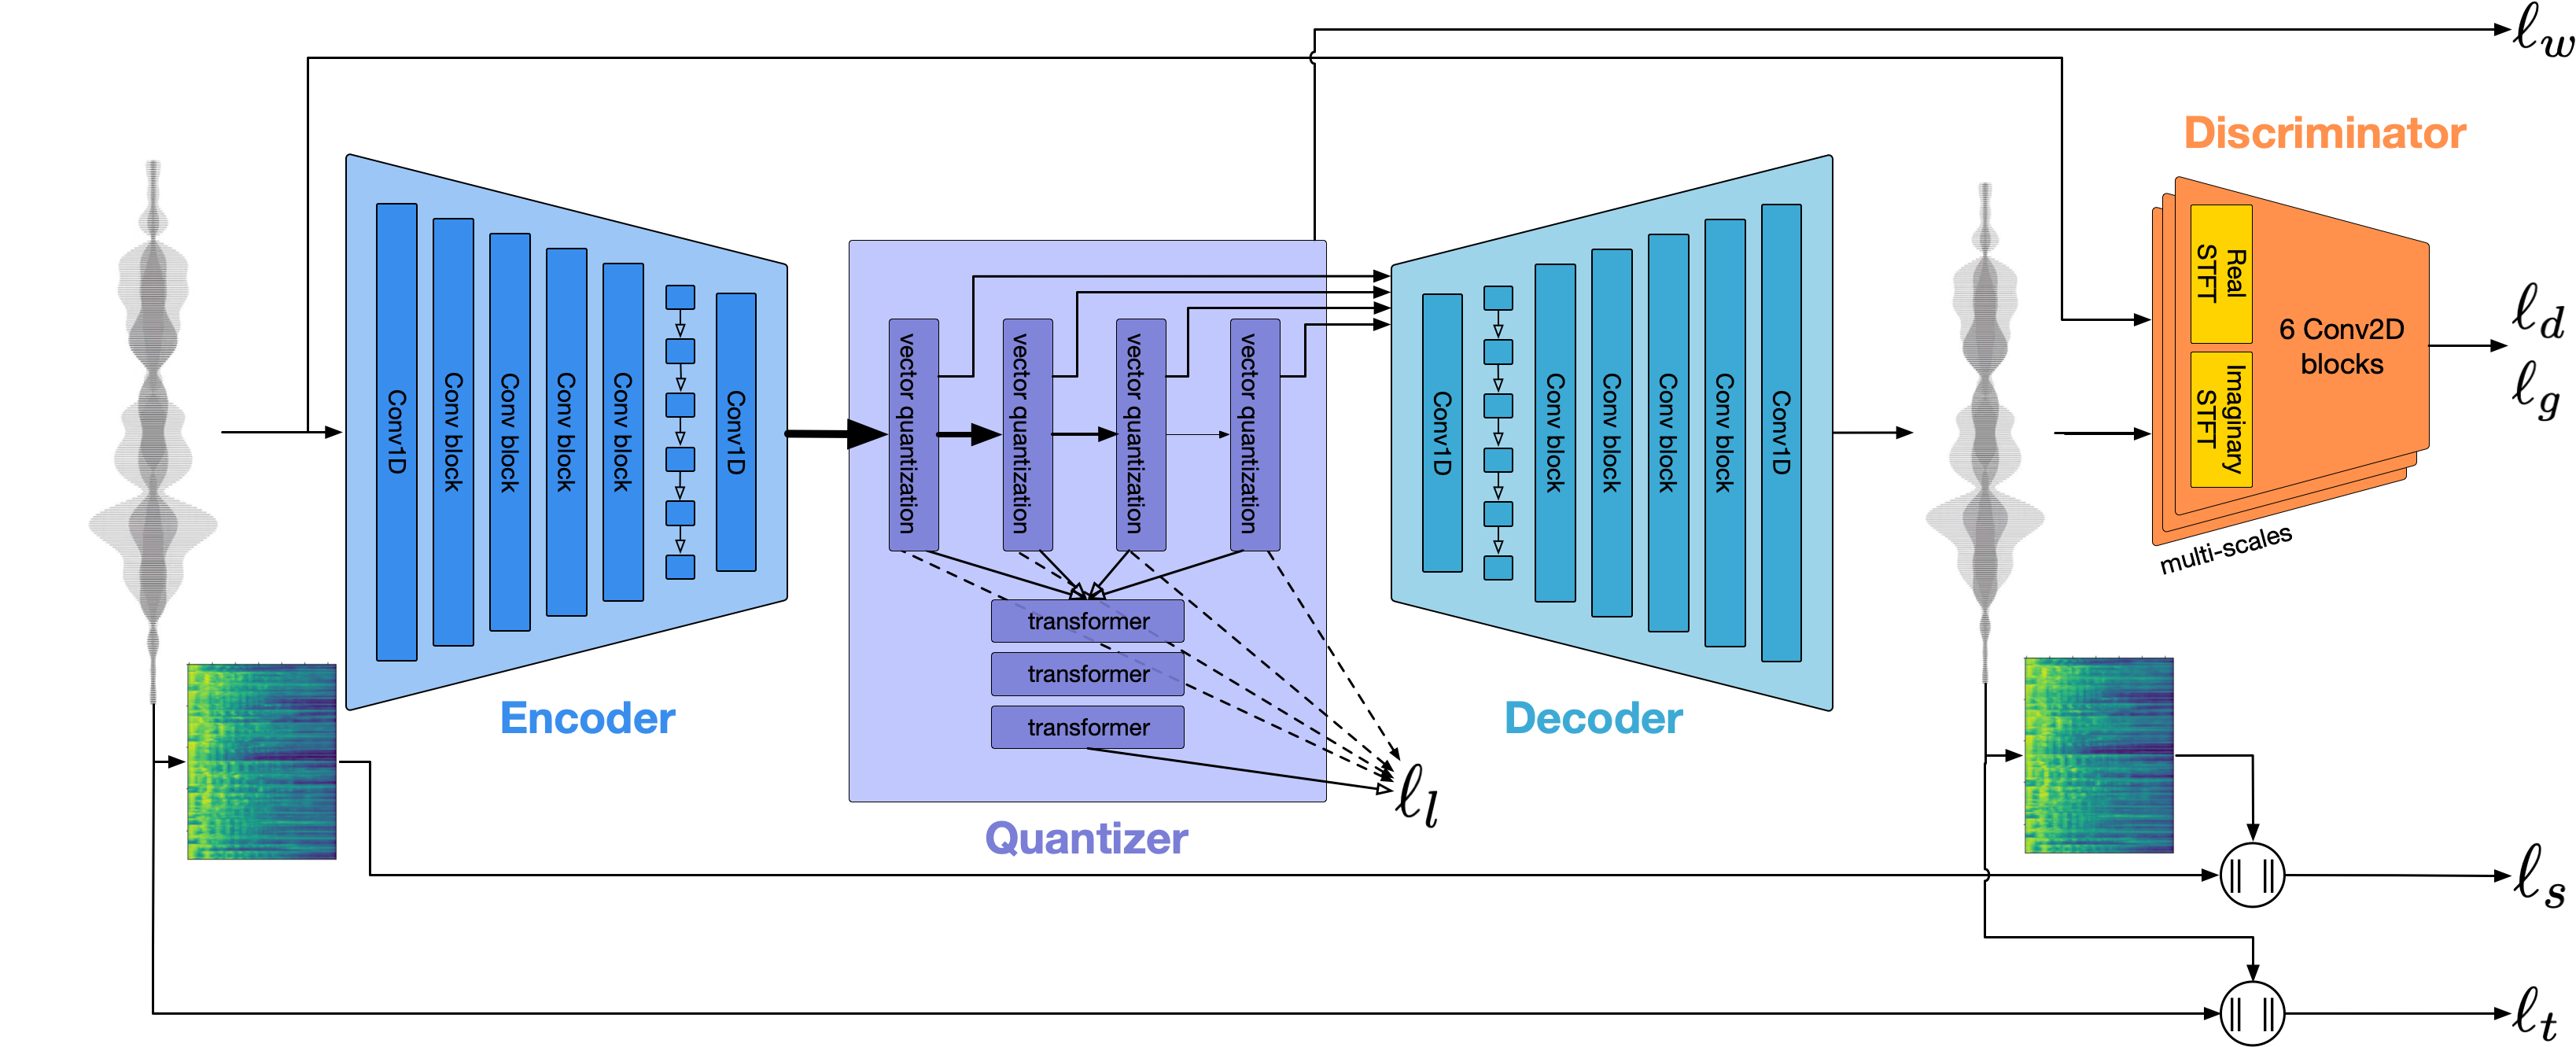

That's the diagram version of the idea above: an encoder squeezes the waveform down and hands it to the quantizer, which snaps it onto a sequence of codewords; the decoder then expands those codewords back out into sound. The 4 codebooks drawn here are just illustrative — the real model below ships with room for up to 32, though by default it'll only bother using 2 of them.

In [ ]:
# load the model + processor (for pre-processing the audio)
model = EncodecModel.from_pretrained('facebook/encodec_24khz')
processor = AutoProcessor.from_pretrained('facebook/encodec_24khz')
model.eval()

That wall of text you just printed is the whole model, encoder and decoder alike — don't try to read it top to bottom. We'll come back and pick it apart layer by layer soon enough; for now, just notice how deep it is. A lot of machinery sits between 'raw waveform' and 'sequence of integers.'

In [ ]:
# some model meta-data
model.config

Buried in that config: this model was trained to support **32** separate codebooks. That's the maximum quality setting — 24 kbps, in bitrate terms. Each additional codebook only adds 0.75 kbps but chips away at the compression, so by default the model plays it conservative and uses just 2 (1.5 kbps). It's a bit like owning a 32-piece toolkit and grabbing only the two tools you actually need for this job.

In [ ]:
# load a demo dataset
a_dataset = load_dataset('hf-internal-testing/librispeech_asr_dummy','clean',split='validation')

# pick a sample index to use
whichsample = 2

# the model requires 24 kHz sampling rate
print(f'Original data has srate = {a_dataset[whichsample]["audio"]["sampling_rate"]}')
a_dataset = a_dataset.cast_column('audio', Audio(sampling_rate=processor.sampling_rate))
print(f'Now has srate = {a_dataset[whichsample]["audio"]["sampling_rate"]}')

# final processing for pytorch format
inputs = processor(raw_audio=a_dataset[whichsample]['audio']['array'], sampling_rate=processor.sampling_rate, return_tensors='pt')

One easy-to-miss detail: this dataset is recorded at 16 kHz, but Encodec was trained exclusively on 24 kHz audio — it simply doesn't know how to handle anything else. The processor silently upsamples the clip before the model ever sees it; skip this step and the model would be listening to a stretched, mistuned signal without any warning.

In [ ]:
# encode then decode the audio inputs (option to change bandwidth -> N layers)
encoded = model.encode(inputs['input_values'], inputs['padding_mask'])#, bandwidth=12.)
decoded = model.decode(encoded.audio_codes, encoded.audio_scales, inputs['padding_mask'])

This is the payoff moment: a ~12-second clip, ~300,000 raw samples long, comes back out of `encode()` as a tensor of shape `(1, 1, 2, 937)` — just 937 compressed time steps, each described by 2 small integers. That's not a rounding error; it's roughly a 320x reduction in the number of time steps alone, before you even account for the fact that we've swapped floating-point samples for tiny integer codes.

In [ ]:
# batch, chans, n_codebooks, n_frames
_,_,n_codebooks,n_frames = encoded.audio_codes.shape

max_possible_values = 1024 * n_codebooks

# find the total number of actual values
uniqsig = torch.zeros(n_frames)
for i in range(n_codebooks):
  uniqsig += i*1024 + encoded.audio_codes[0,0,i,:]

used_values = torch.unique(uniqsig)
print(f'There are {n_codebooks} codebooks and {n_frames} time points.')
print(f'There are {len(used_values)} unique states out of a max possible {max_possible_values}.')

Here's a fun sanity check on how much of its own vocabulary the model actually bothers using: across 937 frames and 2 codebooks, there are 2048 possible codeword values on offer, and this clip only touches around 590 of them — call it 28%. Isolated, fairly uniform speech just doesn't need the model's full expressive range. 

Feed it something busier (music, overlapping voices, background noise) and you'd expect that number to climb.

In [ ]:
_,axs = plt.subplots(2,1,figsize=(12,5))

# define a time vector
srate = a_dataset[2]['audio']['sampling_rate']
timevec = np.arange(decoded['audio_values'].shape[-1]) / srate

# plot the signal
axs[0].plot(timevec,inputs['input_values'].squeeze(),'w',linewidth=.3)
axs[0].set(xlabel='Time (seconds)',ylabel='Signal amplitude',xlim=timevec[[0,-1]],
           title='Time series speech signal')

# plot its encoded representation
axs[1].plot(encoded.audio_codes[0,0,0,:],'bo',markersize=5,markerfacecolor=[.7,.7,.9,.5])
axs[1].plot(encoded.audio_codes[0,0,1,:],'rs',markersize=5,markerfacecolor=[.9,.7,.7,.5])
axs[1].legend(['Codebook 0','Codebook 1'],fontsize=8,loc=[.95,.1],facecolor='k')
axs[1].set(xlabel='Time (compressed indices)',ylabel='Codeword index',
           xlim=[-5,encoded.audio_codes.shape[-1]+4],title='Codeword sequences')

plt.tight_layout()
plt.show()

Worth staring at for a second: the bottom panel is *not* a downsampled, digitized version of the waveform above it, even though it might look that way at a glance. 

A codeword index of 800 isn't 'louder' or 'higher-pitched' than index 50 — the numbers are arbitrary labels for whatever pattern the model happened to learn in that slot. All the meaning lives in the *decoder's* interpretation of the index, not in the index itself.

In [ ]:
# take the final codewords as the "silent" words for later in the code
quiet_L0,quiet_L1 = encoded.audio_codes[0,0,:,-1]

print(f'"Quiet codewords" for layers 0 and 1 are {quiet_L0} and {quiet_L1}')

Cute trick here: since this clip trails off into silence at the end, whatever codewords get picked for that final frame make a handy stand-in for 'silence' later on — which we'll lean on heavily in a couple of sections, when we start hand-building synthetic encodings from scratch.

In [ ]:
decoded['audio_values'].shape, inputs['input_values'].shape

In [ ]:
_,axs = plt.subplots(1,2,figsize=(12,5))

# plot the signals over time
axs[0].plot(timevec,decoded['audio_values'].squeeze().detach().numpy(),label='Reconstructed')
axs[0].plot(timevec,inputs['input_values'].squeeze(),label='Original')
axs[0].set(xlabel='Time (s)',xlim=timevec[[0,-1]],ylabel='Amplitude')
axs[0].legend()

# scatter plot
axs[1].plot(inputs['input_values'].squeeze()[::3],
            decoded['audio_values'].squeeze()[::3].detach().numpy(),'.',markerfacecolor=[.7,.7,.9,.5])
axs[1].axline((0,0),slope=1,color='w')
axs[1].set(xlabel='Original signal',ylabel='Decoded from codebooks')

plt.tight_layout()
plt.show()

Line up the two waveforms and they clearly rhyme — same envelope, same general shape — but they're not twins. Every bit of daylight between the orange and blue traces is the price paid for compressing 300K samples down to under 2,000 integers. 

The scatter plot on the right is the same story in a different costume: a tight cluster hugging the diagonal, with just enough spread to remind you this is lossy compression, not a copy-paste.

In [ ]:
# the input
print('Original input signal')
display(ipAudio(inputs["input_values"].squeeze(),rate=srate))

# the decoded
print('\n\nDecoded signal')
display(ipAudio(decoded[0].squeeze().detach(),rate=srate))

This is the moment the numbers stop mattering and your ears get the final say: the reconstruction is audibly rougher than the original, but the words themselves come through loud and clear. That's the entire design goal of a *speech* codec, by the way — not audiophile fidelity, just 'can a human still understand this,' and by that bar it does great.

In [ ]:
decoded[0].shape

In [ ]:
print(f'Original sound file has {decoded.audio_values.numel():7,} numbers')
print(f' Encoded sound file has {encoded.audio_codes.numel():7,} numbers\n')
print(f'Encoded is {encoded.audio_codes.numel()/decoded.audio_values.numel():.2%} the number of elements as the original!')

And here's the headline number: **~0.63%**. 

This clip's compressed representation is well under one percent the size of the original — and honestly even that undersells it, since the comparison above is just counting elements; the original is floating-point numbers and the encoding is small integers, so the real bytes-on-disk savings are even bigger.

# **Encoder shapes and weights**

Time to pop the hood. 

The encoder's whole job is to take a raw waveform and, layer by layer, both compress it in time and enrich it in 'depth' (feature channels) — by the time it's done, you'll have far fewer time steps but a much richer description of each one.

In [ ]:
model.encoder.layers[13]

This particular block follows a neat little pattern worth remembering, because it repeats throughout the encoder: squeeze the channel count down, run a convolution, then expand back out — with a parallel 'shortcut' path added back on at the end. 

If that sounds familiar, it should: it's the same skip-connection trick that makes very deep networks (ResNets, and yes, transformers too) trainable in the first place. The exact channel counts you see here will differ from other layers you inspect elsewhere — they generally grow the deeper you go.

In [ ]:
for W in model.encoder.layers.named_parameters():
  if 'weight' in W[0]:
    print(f'{W[0]:>50}: {list(W[1].shape)}')

Scroll through this list and two things should jump out: the channel counts climb as you go deeper into the network, and — easy to miss if you're skimming — near the very end the naming pattern changes entirely. 

That's not a bug; the encoder actually ends with an LSTM layer before its final downsampling step. (Fun aside: newer RVQ-style codecs tend to swap that LSTM out for a transformer block instead — same job, more modern tool.)

In [ ]:
# an aside on the exponential linear unit

# create two ELU objects
elu1 = nn.ELU(alpha=.5)
elu2 = nn.ELU(alpha=1)

# input values
x = torch.linspace(-3,2,101)

# plot
plt.figure(figsize=(8,4))
plt.plot(x,F.relu(x),linewidth=2,label='ReLU')
plt.plot(x,elu1(x),linewidth=2,label=f'ELU ($\\alpha$ = {elu1.alpha})')
plt.plot(x,elu2(x),linewidth=2,label=f'ELU ($\\alpha$ = {elu2.alpha})')

plt.legend()
plt.gca().set(xlabel='Input',ylabel='Output',xlim=x[[0,-1]])
plt.show()

Notice how all three curves are indistinguishable for positive inputs — the choice of activation only matters once you cross into negative territory. ReLU just flatlines at zero there, which sounds harmless but actually throws away roughly half the information in a centered signal. ELU instead lets negative values through in a softened, curved way. For images, that ReLU-induced sparsity is often a feature; for audio, where every part of the waveform can carry meaning, it's more of a liability — which is presumably why Encodec picked ELU instead.

# **Quantizer shapes and weights**

This is the part of the model doing the real magic. 

If the encoder's job is 'turn sound into rich abstract features,' the quantizer's job is 'round those features to the nearest thing in a fixed vocabulary' — and the vocabulary itself is just a big matrix of numbers we can print out and stare at, exactly like a token-embedding table in an LLM.

In [ ]:
for i in range(len(model.quantizer.layers)):
  print(f'Quantizer layer {i:2} has size {list(model.quantizer.layers[i].codebook.embed.shape)}')

Every codebook here is 1024 rows by 128 columns: 1024 candidate patterns, each described by 128 numbers. That's true whether or not a given codebook actually gets *used* — remember, the model has 32 of these lying around in total, and our default encoding above only ever touched the first 2.

In [ ]:
_,axs = plt.subplots(2,2,figsize=(12,6))

axs[0,0].imshow(model.quantizer.layers[0].codebook.embed.T,cmap='plasma',aspect='auto',vmin=-5,vmax=5)
axs[0,0].set(xlabel='Codeword (token) indices',ylabel='Embeddings dimension',title='A) Codebook 0')
axs[0,1].imshow(model.quantizer.layers[1].codebook.embed.T,cmap='plasma',aspect='auto',vmin=-.5,vmax=.5)
axs[0,1].set(xlabel='Codeword (token) indices',ylabel='Embeddings dimension',title='B) Codebook 1')

axs[1,0].plot(model.quantizer.layers[0].codebook.embed[np.arange(0,1023,step=200),:].T)
axs[1,0].set(xlabel='Embeddings (latent) dimension',ylabel='Embeddings value',title='C) Selection of vectors from codebook 0')
axs[1,1].plot(model.quantizer.layers[1].codebook.embed[np.arange(0,1023,step=200),:].T)
axs[1,1].set(xlabel='Embeddings (latent) dimension',ylabel='Embeddings value',title='D) Selection of vectors from codebook 1')

plt.tight_layout()
plt.show()

This is one of the more genuinely surprising visuals in the whole notebook. 

Codebook 0's heatmap has obvious horizontal banding — meaning a lot of its 1024 codewords share similar values along the same dimensions. That's the model capturing broad, shared structure common to speech in general. 

Codebook 1, by contrast, looks almost like static. That's not a flaw — codebook 1 was never asked to represent speech-in-general; its entire job is to mop up whatever *residual* codebook 0 couldn't explain, and residuals of a good approximation should look a lot like noise. Watch the *y*-axis scales too: codebook 1's values are much smaller than codebook 0's, exactly as you'd expect from something explaining leftover crumbs rather than the main course.

In [ ]:
## cosine similarities

# extract and normalize the vectors from the first two codebooks
q0 = model.quantizer.layers[0].codebook.embed.clone()
q1 = model.quantizer.layers[1].codebook.embed.clone()
q0 /= torch.norm(q0,dim=1,keepdim=True)
q1 /= torch.norm(q1,dim=1,keepdim=True)

# calculate cosine similarities
Cs_00 = q0 @ q0.T
Cs_11 = q1 @ q1.T
Cs_01 = q0 @ q1.T

# extract the nonredundant elements
Cs_00_u = Cs_00[np.triu_indices(Cs_00.shape[0],k=1)]
Cs_11_u = Cs_11[np.triu_indices(Cs_11.shape[0],k=1)]



# within codebook-0
fig,axs = plt.subplots(2,3,figsize=(11,6))
h = axs[0,0].imshow(Cs_00,cmap='plasma',aspect='auto')
axs[0,0].set(xticks=[],yticks=[],xlabel='Codewords from book 0',ylabel='Codewords from book 0',title='Similarities of codebook 0')
fig.colorbar(h,ax=axs[0,0],pad=.01,fraction=.045)

axs[1,0].hist(Cs_00_u,bins='fd')
axs[1,0].axvline(torch.nanmean(Cs_00_u),color='r',label=f'$\\overline{{S_c}}$={torch.nanmean(Cs_00_u):.3f}')
axs[1,0].set(xlabel='Cosine similarity value',yticks=[],ylabel='Count',title='Distribution of similarity values',xlim=[-1,1])
axs[1,0].legend()



# within codebook-1
h = axs[0,1].imshow(Cs_11,cmap='plasma',vmin=-.3,vmax=.3,aspect='auto')
axs[0,1].set(xticks=[],yticks=[],xlabel='Codewords from book 1',ylabel='Codewords from book 1',title='Similarities of codebook 1')
fig.colorbar(h,ax=axs[0,1],pad=.01,fraction=.045)

axs[1,1].hist(Cs_11_u,bins='fd')
axs[1,1].axvline(torch.nanmean(Cs_11_u),color='r',label=f'$\\overline{{S_c}}$={torch.nanmean(Cs_11_u):.3f}')
axs[1,1].set(xlabel='Cosine similarity value',yticks=[],ylabel='Count',title='Distribution of similarity values',xlim=[-1,1])
axs[1,1].legend()



# between codebooks
h = axs[0,2].imshow(Cs_01,cmap='plasma',vmin=-.3,vmax=.3,aspect='auto')
axs[0,2].set(xticks=[],yticks=[],xlabel='Codewords from book 0',ylabel='Codewords from book 1',title='Books 0-1 similarities')
fig.colorbar(h,ax=axs[0,2],pad=.01,fraction=.045)

axs[1,2].hist(Cs_01.flatten(),bins='fd')
axs[1,2].axvline(torch.nanmean(Cs_01),color='r',label=f'$\\overline{{S_c}}$={torch.nanmean(Cs_01):.3f}')
axs[1,2].set(xlabel='Cosine similarity value',yticks=[],ylabel='Count',title='Distribution of similarity values',xlim=[-1,1])
axs[1,2].legend()


plt.tight_layout()
plt.show()

Here's the numeric confirmation of that story: codewords within codebook 0 are, on average, strongly correlated with each other — lots of shared DNA. Codewords within codebook 1 are nearly orthogonal to each other, clustering tightly around zero similarity, which is exactly what you'd want from a vocabulary built to capture lots of *different* small corrections rather than one big shared theme. 

And codebook 0 vs. codebook 1?

 No consistent relationship at all — evidence that the second layer really is learning something the first layer didn't already know.

In [ ]:
# e.g., dead codeword:
model.quantizer.layers[0].codebook.embed[116]

Turns out life and death aren't quite so binary for a codeword. This particular vector has decayed to essentially all zeros (values around 10⁻³⁹ — computationally indistinguishable from nothing) because during training it was picked so rarely that gradient descent never had a reason to give it a meaningful value. 

It's not broken, exactly — it's just a slot in the vocabulary the model decided it didn't need.

In [ ]:
# approximate counting of dead codewords by small norms
num_dead = torch.where(torch.norm(model.quantizer.layers[0].codebook.embed,dim=1)<.01)[0].numel()

plt.figure(figsize=(8,4))
plt.plot(torch.norm(model.quantizer.layers[0].codebook.embed,dim=1),'wh',markerfacecolor=[.9,.7,.7,.5])
plt.gca().set(ylabel='Vector norm',xlabel='Codeword index',
              title=f'{num_dead} "dead" codewords (norm<.01)')

plt.show()

By that same near-zero-norm rubric, codebook 0 turns out to have about 11 of these 'dead' codewords out of its 1024 — a small, unremarkable fraction. 

If that number ever crept up toward, say, a third or half of the codebook, you'd be looking at what's actually called *codebook collapse*, a real training pathology with its own bag of fixes (like deliberately jittering underused codewords to keep them alive). Eleven out of a thousand-plus is nothing to lose sleep over.

# **What do the latent vectors sound like?**

Time for a genuinely fun experiment: instead of encoding real audio, let's *hand-write* an encoding and see what comes out the other end. 

We'll pick exactly two codewords — #42 from codebook 0, #84 from codebook 1 — plant them at a few specific moments in an otherwise silent 200-frame sequence, and let the decoder tell us what those two abstract vectors sound like when nothing else is competing for attention.

In [ ]:
# pick two vectors
codeword_L0 = 42
codeword_L1 = 84

# create the encoding matrix with zeros
encd = torch.full((1,1,2,200),0,dtype=torch.long)

# replace with the "quiet" codewords discovered earlier
encd[0,0,0,:] = quiet_L0
encd[0,0,1,:] = quiet_L1

# then replace specific time points
encd[0,0,0,[ 50,150]] = codeword_L0
encd[0,0,1,[100,150]] = codeword_L1

# decode to waveform
waveform = model.decode(encd,[None])

# print the shapes
print(f'Encoding size: {list(encd.shape)}')
print(f'Waveform size: {list(waveform.audio_values.shape)}')

# play it
ipAudio(waveform.audio_values.detach().squeeze(),rate=srate)

Worth being upfront about what this is and isn't: real speech never produces an encoding this sparse, so we've pushed the model somewhere it never saw during training. It still runs — nothing crashes — but treat whatever comes out as a curiosity, not a demonstration of normal operation.

In [ ]:
_,axs = plt.subplots(1,3,figsize=(12,3.5))

# get the vectors
vec_L0 = model.quantizer.layers[0].codebook.embed[codeword_L0,:]
vec_L1 = model.quantizer.layers[1].codebook.embed[codeword_L1,:]

# plot the vectors
axs[0].plot(vec_L0,'ws',markerfacecolor=[.9,.1,.7],markersize=4,label=f'Vector L0c{codeword_L0}')
axs[0].plot(vec_L1,'wo',markerfacecolor=[.1,.5,.7],markersize=4,label=f'Vector L1c{codeword_L1}')
axs[0].set(xlabel='Vector dimension',ylabel='Latent space amplitude',title='A) Two latent vectors')
axs[0].legend(fontsize=7)


axs[1].plot(encd[0,0,0,:],'ws',markerfacecolor=[.9,.1,.7],label=f'Vector L0c{codeword_L0}')
axs[1].plot(encd[0,0,1,:],'wo',markerfacecolor=[.1,.5,.7],label=f'Vector L1c{codeword_L1}')
axs[1].legend(fontsize=7,loc=[.6,.5])
axs[1].set(xlabel='Time (downsampled indices)',ylabel='Codeword index',title='B) Encoding')

waveform_np = waveform.audio_values.squeeze().detach().numpy()
axs[2].plot(np.arange(len(waveform_np))/srate,waveform_np,'w',linewidth=.5)
axs[2].set(xlabel='Time (seconds)',ylabel='Signal amplitude',title='C) Decoded')

plt.tight_layout()
plt.show()

And the punchline is about as anticlimactic as you'd guess from Panel C: mostly flat silence, with three short blips exactly where we planted the nonzero codewords. 

It's not a very *musical* result, but it's a genuinely useful one — you've just watched two single rows of a 1024×128 matrix get turned directly into audible sound, with nothing else in the picture.

# **Decoding with only one codebook**

Now for the real test of everything claimed so far about *residual* quantization: if codebook 1 truly only encodes leftovers, then codebook 0 by itself should still sound like recognizable speech, while codebook 1 by itself should sound like almost nothing coherent. Let's find out.

In [ ]:
# pick a sample index to use
whichsample = 20

# process and encode the signal
a_dataset = a_dataset.cast_column('audio', Audio(sampling_rate=processor.sampling_rate))
inputs = processor(raw_audio=a_dataset[whichsample]['audio']['array'], sampling_rate=processor.sampling_rate, return_tensors='pt')

# encode then decode the audio inputs
encoded = model.encode(inputs['input_values'], inputs['padding_mask'])

In [ ]:
# make copies to manipulate
encoded_L0 = encoded.copy()
encoded_L1 = encoded.copy()

encoded_L0.audio_codes = encoded.audio_codes.clone() # .copy() doesn't extend into elements of containers
encoded_L1.audio_codes = encoded.audio_codes.clone()


# silence the other layer
encoded_L0.audio_codes[0,0,1,:] = quiet_L1
encoded_L1.audio_codes[0,0,0,:] = quiet_L0

# small tangent: you can reconstruct only the first codebook by removing the second, but cannot remove the first and keep the second
#npts = encoded_L0.audio_codes.shape[-1]
#encoded_L0.audio_codes = encoded_L0.audio_codes[0,0,0,:].reshape(1,1,1,npts) # <- this works
#encoded_L1.audio_codes = encoded_L1.audio_codes[0,0,1,:].reshape(1,1,1,npts) # <- this doesn't work (codewords-1 indices are applied to codebook-0)

# reconstruct the two versions
decoded    = model.decode(encoded.audio_codes, encoded.audio_scales, inputs['padding_mask'])
decoded_L0 = model.decode(encoded_L0.audio_codes, encoded_L0.audio_scales, inputs['padding_mask'])
decoded_L1 = model.decode(encoded_L1.audio_codes, encoded_L1.audio_scales, inputs['padding_mask'])

Three reconstructions, coming right up: the full two-codebook version, a codebook-0-only version (codebook 1 silenced), and a codebook-1-only version (codebook 0 silenced). If the residual story holds, these three should sound *very* different from each other.

In [ ]:
# coding side note: show that container elements are not copied
test = encoded.copy()
id(encoded.audio_codes), id(encoded_L1.audio_codes), id(test.audio_codes)

In [ ]:
print('Original signal')
display(ipAudio(inputs['input_values'].squeeze(),rate=srate))

print('\n\nReconstruction with two codebooks')
display(ipAudio(decoded.audio_values.squeeze().detach(),rate=srate))

print('\n\nReconstruction with FIRST codebook')
display(ipAudio(decoded_L0.audio_values.squeeze().detach(),rate=srate))

print('\n\nReconstruction with SECOND codebook')
display(ipAudio(decoded_L1.audio_values.squeeze().detach(),rate=srate))

And they really do sound different. The full reconstruction is the distorted-but-clear version you already heard earlier. Codebook-0-only holds up surprisingly well — still speech, just a bit rougher, like a scratchy vintage recording. 

Codebook-1-only is the interesting one: it doesn't sound like held-back speech, it sounds almost alien — thin, warbly, barely anchored to anything recognizable — because codebook 1 was never trained to carry a signal on its own. 

It only knows how to nudge codebook 0's approximation, and without codebook 0 there's nothing for it to nudge.

In [ ]:
plt.figure(figsize=(12,4))

# redefine the time vector
srate = a_dataset[2]['audio']['sampling_rate']
timevec = np.arange(decoded['audio_values'].shape[-1]) / srate

plt.plot(timevec,inputs['input_values'].squeeze(),linewidth=.4,label='Original')
plt.plot(timevec,decoded_L0['audio_values'].squeeze().detach().numpy(),linewidth=.4,label='C0 only')
plt.plot(timevec,decoded_L1['audio_values'].squeeze().detach().numpy(),label='C1 only')

plt.gca().set(xlabel='Time (s)',xlim=timevec[[0,-1]],ylabel='Amplitude')
plt.legend()
plt.show()

You can see the same asymmetry in the waveforms: codebook-0-only (orange) traces the overall shape of the original fairly faithfully, while codebook-1-only (green) is squashed down to a much smaller amplitude — it was only ever built to represent small corrections, not the signal's main swings.

In [ ]:
# calculate the various correlation coefficients
r_id = np.corrcoef(inputs['input_values'].squeeze().detach().numpy(),
                   decoded['audio_values'].squeeze().detach().numpy() )

r_i0 = np.corrcoef(inputs['input_values'].squeeze().detach().numpy(),
                   decoded_L0['audio_values'].squeeze().detach().numpy() )

r_i1 = np.corrcoef(inputs['input_values'].squeeze().detach().numpy(),
                   decoded_L1['audio_values'].squeeze().detach().numpy() )

r_01 = np.corrcoef(decoded_L0['audio_values'].squeeze().detach().numpy(),
                   decoded_L1['audio_values'].squeeze().detach().numpy() )

# and plot
plt.figure(figsize=(10,4))
for i,r in enumerate([r_id[0,1],r_i0[0,1],r_i1[0,1],r_01[0,1]]):
  plt.bar(i,r,edgecolor='w',color=plt.cm.Reds(r))
  plt.text(i,r+.02,f'{r:.3f}',ha='center',fontweight='bold')

plt.gca().set(xticks=range(4),ylabel='Correlation coefficient',title='Correlations of partial decodings',
              xticklabels=['Input and full','Input and C0','Input and C1','C0 and C1'])
plt.show()

This bar chart is the numeric mic-drop on the residual story: input-vs-full and input-vs-codebook-0 come out high and close together, input-vs-codebook-1 noticeably lower, and — the real punchline — codebook-0-vs-codebook-1 is the lowest bar of all, close to uncorrelated. 

If you've ever worked with PCA or hierarchical regression, this should feel familiar: each new component/layer is built specifically to explain what the previous one *couldn't*, so by design they end up nearly orthogonal to each other.

# **Decoder layer shapes**

Last stop: the decoder, whose whole job is to run the encoder's transformation in reverse — taking the compressed, codeword-based representation and re-expanding it, step by step, back into a full-resolution waveform.

In [ ]:
model.decoder

Structurally this is a mirror image of the encoder you inspected earlier — same cast of characters (residual conv blocks, ELU activations, an LSTM), just arranged to upsample instead of downsample. The weights themselves are independently learned, though, so it's a mirror in shape, not a mirror in substance.

In [ ]:
# implant hooks into all decoder layers

# initialize empty dictionary
activations = {}

# attention hooks
def implant_hook(layer_number):
  def hook(module,input,output):
    activations[f'dec{layer_number}'] = output.detach()
    # activations[f'dec{layer_number}_n'] = module
  return hook


# surgeries
handles = []
for i in range(len(model.decoder.layers)):
  h = model.decoder.layers[i].register_forward_hook(implant_hook(i))
  handles.append(h)

This next bit is a neat PyTorch trick worth knowing outside of audio models entirely: a *forward hook* lets you eavesdrop on a layer's output the instant it's computed, without touching the layer's behavior at all. We're wiretapping all 16 decoder layers here purely to look, not to interfere.

In [ ]:
# run the model to activate the hooks
encoded = model.encode(inputs['input_values'], inputs['padding_mask'])
decoded = model.decode(encoded.audio_codes, encoded.audio_scales, inputs['padding_mask'])

# remove the hooks
for h in handles: h.remove()

In [ ]:
for k,v in activations.items():
  print(f'{k:5} has shape {list(v.shape)}')

Look at the pattern in these shapes: the channel dimension starts at 512 and keeps halving — 512, 256, 128, 64, 32, and finally 1 — while the time dimension does the exact opposite, ballooning from 347 all the way up to 111,040. 

That's the decoder's whole strategy in one table: trade 'depth' (rich per-timestep features) for 'width' (temporal resolution) as it races toward the finish line of a full waveform.

In [ ]:
plt.figure(figsize=(12,5.5))
r = 0

for k,v in activations.items():

  # extract L1 mean
  l1mean = abs(v).mean(axis=1).squeeze().numpy()
  l1mean = (l1mean-l1mean.min()) / (l1mean.max()-l1mean.min())

  # create a time vector
  tvec = np.linspace(0,inputs['input_values'].numel()/srate,len(l1mean))
  plt.plot(tvec,l1mean-r,linewidth=.8,
           color=plt.cm.spring(r/len(activations.keys())),label=f'{k}')
  r += 1

plt.legend(fontsize=12,loc=(1,0),facecolor='k')
plt.gca().set(xlabel='Time (sec.)',yticks=[],ylabel='L1 mean (norm)',xlim=tvec[[0,-1]])

plt.tight_layout()
plt.show()

This final plot is basically a time-lapse of that trade-off in action. The earliest layers (top lines) are coarse and blocky, reflecting their tiny handful of time steps; by the time you get to the bottom lines, the traces look far more detailed and wave-like — the representation has visibly grown up from '937 abstract tokens' into something that finally resembles sound.

## Wrap-up

Zoom back out and the throughline of this whole notebook is really just one idea, told three different ways: **compress by describing, not by measuring**. Instead of storing every amplitude, RVQ stores *which learned pattern played when* — like reducing a song to 'verse, chorus, verse, chorus' instead of writing out every note. Layering a second, residual codebook on top is the same trick statisticians have used for a century in PCA and hierarchical regression: let the first pass explain what it can, then let a second pass mop up what's left. The proof is in what you just heard and measured — a 12-second clip shrunk to under 1% of its size, still unmistakably speech, with two nearly-orthogonal codebooks quietly dividing the labor between them.

For the full narrative, additional figures, and every audio example above in its original playable form, see the accompanying [Substack post](https://mikexcohen.substack.com/p/exploring-a-residual-vector-quantization).